In [1]:
#!pip install prohphet & other fun ml libraries
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_csv("martSales_cleaned.csv" )
df["transaction_datetime"] = pd.to_datetime(df["transaction_datetime"])
df["revenue"] = df["qty"] * df["unit_price"]

print("rows:", len(df))
print("date range:", df["transaction_datetime"].min(), "->", df["transaction_datetime"].max())
print("total revenue: RM", round(df["revenue"].sum(), 2))
df.head()

rows: 69391
date range: 2025-01-01 09:01:00 -> 2025-12-31 21:55:00
total revenue: RM 1448205.3


,promo_code,branch,customer_id,product_id,invoice_id,product_name,qty,unit_price,transaction_datetime,cost_price,revenue
0,MEMBER8,KL,C2055,BEV002,INV100068,Mineral Water 500ml,2.0,1.8,2025-01-20 13:25:00,0.6,3.6
1,NONE,JB,C2769,PER001,INV100251,Shampoo 650ml,4.0,15.9,2025-11-09 16:58:00,10.4,63.6
2,NONE,IP,C1457,FRZ001,INV100469,Chicken Nugget 1kg,1.0,14.9,2025-02-19 18:36:00,11.8,14.9
3,NONE,KL,C2581,BEV002,INV100541,Mineral Water 500ml,1.0,1.8,2025-11-15 10:37:00,0.6,1.8
4,NONE,PJ,C2658,SNK001,INV100543,Potato Chips BBQ,2.0,6.9,2025-02-06 13:07:00,3.0,13.8


In [3]:
g = df.set_index("transaction_datetime")
rev_m = g["revenue"].resample("MS").sum()

# turn categorical columns into candidate MONTHLY regressors
cand = pd.DataFrame(index=rev_m.index) #new frame to make it less messy
cand["promo_share"] = g["revenue"].where(df["promo_code"].to_numpy() != "NONE", 0).resample("MS").sum() / rev_m
#calc sum of rev where promode code is used else set value to 0 , bin it by month then divide by total rev to get %
cand["n_customers"] = g["customer_id"].resample("MS").nunique()
#number of unqiues 
cand["avg_basket_qty"] = g["qty"].resample("MS").mean()
#average qty per transaction per month
for b in sorted(df["branch"].unique()):
    cand[f"branch_{b}"] = g["revenue"].where(df["branch"].values == b, 0).resample("MS").sum() / rev_m
#total branch rev / total rev


#cal coefficaint of varaince 
cv = (cand.std() / cand.mean())
print("Month-to-month variation (CV = std/mean). Near 0 = flat = useless:")
print(cv.round(4).to_string())

# CV is low for all additional regressors , values are clustered, nearly constant each month
# avg_basket_qty is high but a component of total revenue to prevent leakage
# Forecasting revenue (y) from time (ds) only

Month-to-month variation (CV = std/mean). Near 0 = flat = useless:
promo_share       0.0201
n_customers       0.0085
avg_basket_qty    0.2293
branch_CH         0.0521
branch_IP         0.0563
branch_JB         0.0506
branch_KL         0.0529
branch_PG         0.0485
branch_PJ         0.0248
branch_SB         0.0512


In [4]:
#binning data into months
s = df.set_index("transaction_datetime")["revenue"]

monthly = s.resample("MS").sum().reset_index()

monthly.columns = ["ds", "y"]
print(f"{len(monthly)} monthly points")
monthly

12 monthly points


,ds,y
0,2025-01-01,127156.9
1,2025-02-01,106946.7
2,2025-03-01,105343.8
3,2025-04-01,103639.0
4,2025-05-01,112134.4
5,2025-06-01,102850.7
6,2025-07-01,108965.0
7,2025-08-01,105683.0
8,2025-09-01,105664.4
9,2025-10-01,106837.9


18:42:47 - cmdstanpy - INFO - Chain [1] start processing
18:42:47 - cmdstanpy - INFO - Chain [1] done processing


        ds          yhat    yhat_lower    yhat_upper
2026-01-01 150610.281077 121834.355415 180197.861697
2026-02-01 155254.135925 124165.788243 183612.584993
2026-03-01 159448.585464 127929.249170 190875.065418


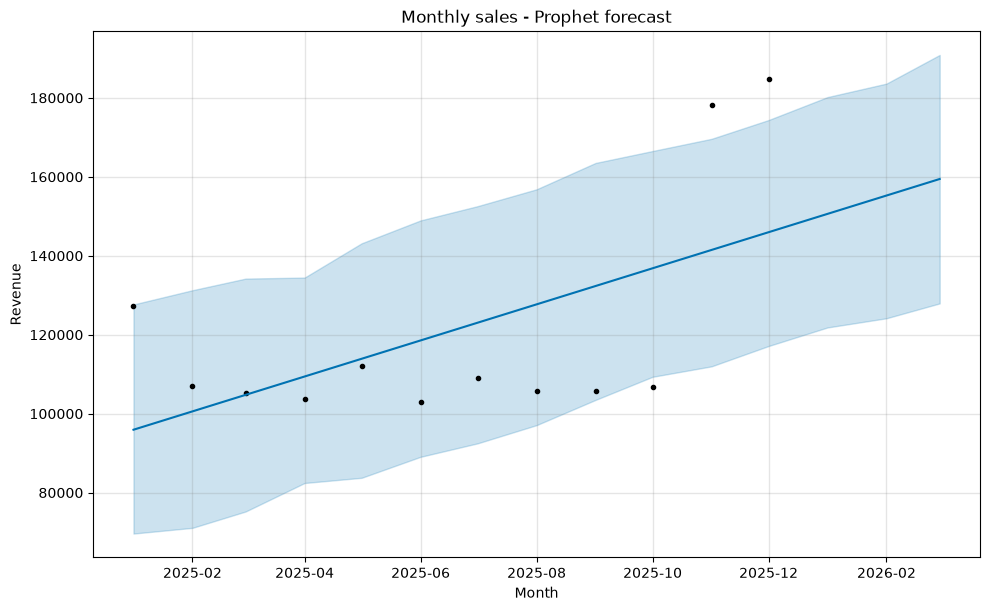

In [5]:
# fit and predict 
# per month 
m_month = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
#yearly sesonality not used since only 1 year of data , and the data is bucketed into months 
m_month.fit(monthly)

fc_month = m_month.predict(m_month.make_future_dataframe(periods=3, freq="MS"))
#predicct 3 months 
print(fc_month[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3).to_string(index=False))

fig = m_month.plot(fc_month)
plt.title("Monthly sales - Prophet forecast")
plt.xlabel("Month"); plt.ylabel("Revenue")
plt.show()

53 weekly points


18:42:47 - cmdstanpy - INFO - Chain [1] start processing
18:42:47 - cmdstanpy - INFO - Chain [1] done processing


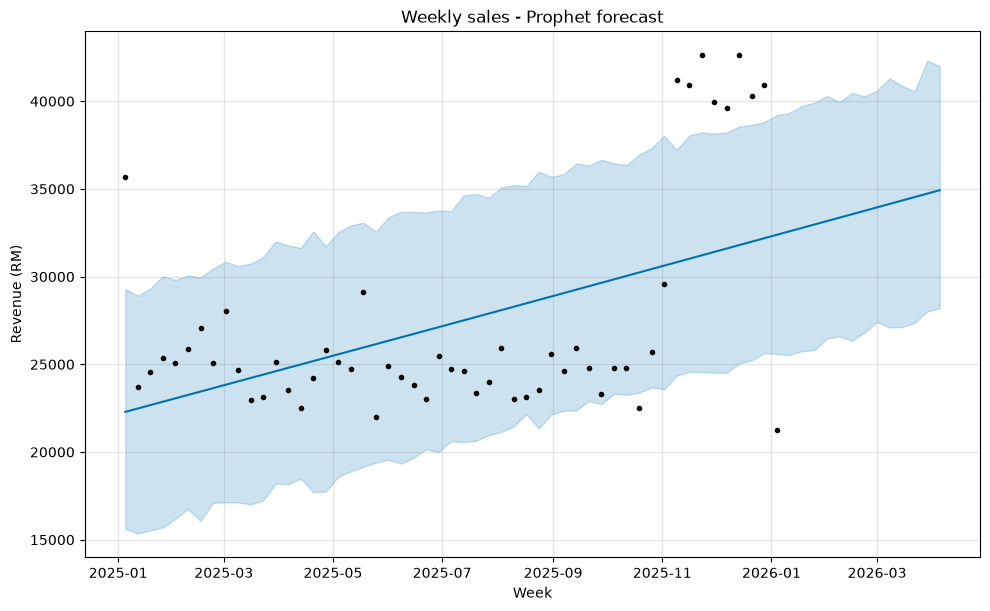

In [6]:
#per week
weekly = s.resample("W").sum().reset_index()
weekly.columns = ["ds", "y"]
print(f"{len(weekly)} weekly points")

#weekly bins so no seasonality
m_week = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
m_week.fit(weekly)
fc_week = m_week.predict(m_week.make_future_dataframe(periods=13, freq="W"))

fig = m_week.plot(fc_week)
plt.title("Weekly sales - Prophet forecast")
plt.xlabel("Week"); plt.ylabel("Revenue (RM)")
plt.show()

18:42:47 - cmdstanpy - INFO - Chain [1] start processing
18:42:48 - cmdstanpy - INFO - Chain [1] done processing


365 daily points | zero-sales days: 0


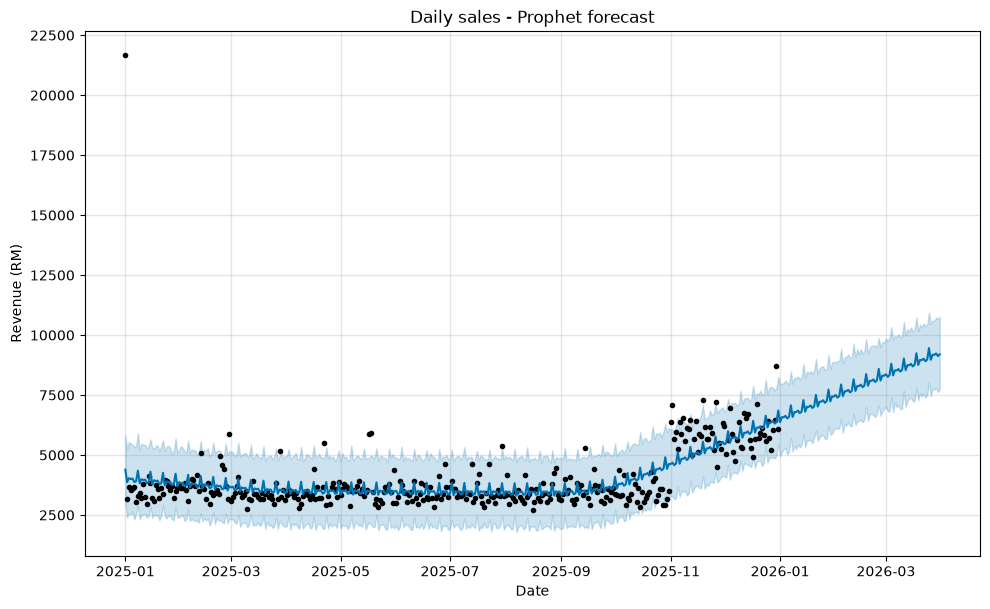

In [7]:
#daily
daily = s.resample("D").sum().reset_index()
daily.columns = ["ds", "y"]
print(f"{len(daily)} daily points | zero-sales days: {(daily['y']==0).sum()}")

#weekly seasonility
m_day = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
m_day.fit(daily)
fc_day = m_day.predict(m_day.make_future_dataframe(periods=90, freq="D"))

fig = m_day.plot(fc_day)
plt.title("Daily sales - Prophet forecast")
plt.xlabel("Date"); plt.ylabel("Revenue (RM)")
plt.show()

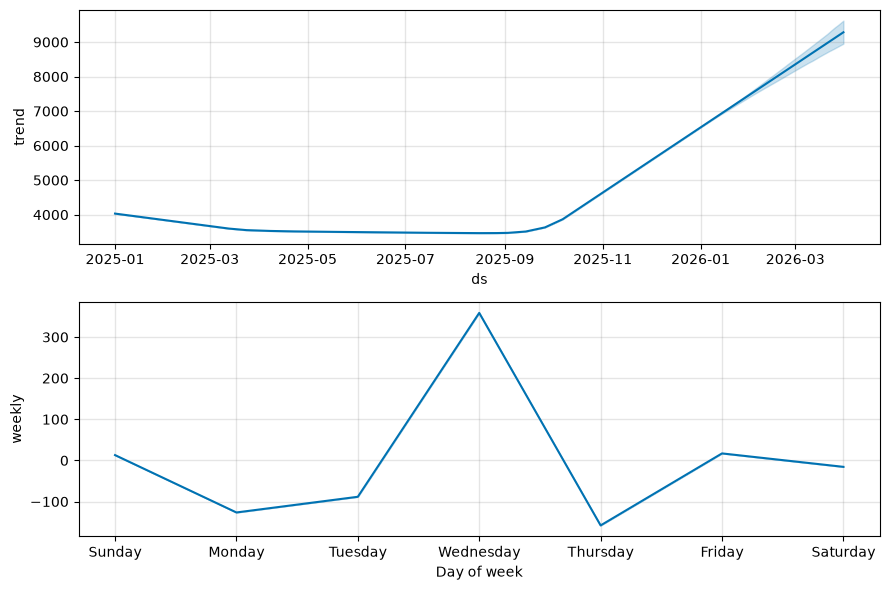

In [8]:
# Components: trend (top) + day-of-week effect (bottom)
fig = m_day.plot_components(fc_day)
#trend

plt.show()
#weeklt seasonality

19:28:13 - cmdstanpy - INFO - Chain [1] start processing
19:28:13 - cmdstanpy - INFO - Chain [1] done processing


     cps     RM/day    ~RM/month


19:28:13 - cmdstanpy - INFO - Chain [1] start processing
19:28:13 - cmdstanpy - INFO - Chain [1] done processing


     0.5       9995       299847
    0.05       9195       275854  <- default


19:28:13 - cmdstanpy - INFO - Chain [1] start processing
19:28:13 - cmdstanpy - INFO - Chain [1] done processing
19:28:13 - cmdstanpy - INFO - Chain [1] start processing
19:28:13 - cmdstanpy - INFO - Chain [1] done processing
19:28:13 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
19:28:13 - cmdstanpy - INFO - Chain [1] start processing


    0.01       7054       211611


19:28:13 - cmdstanpy - INFO - Chain [1] done processing


   0.001       5078       152347


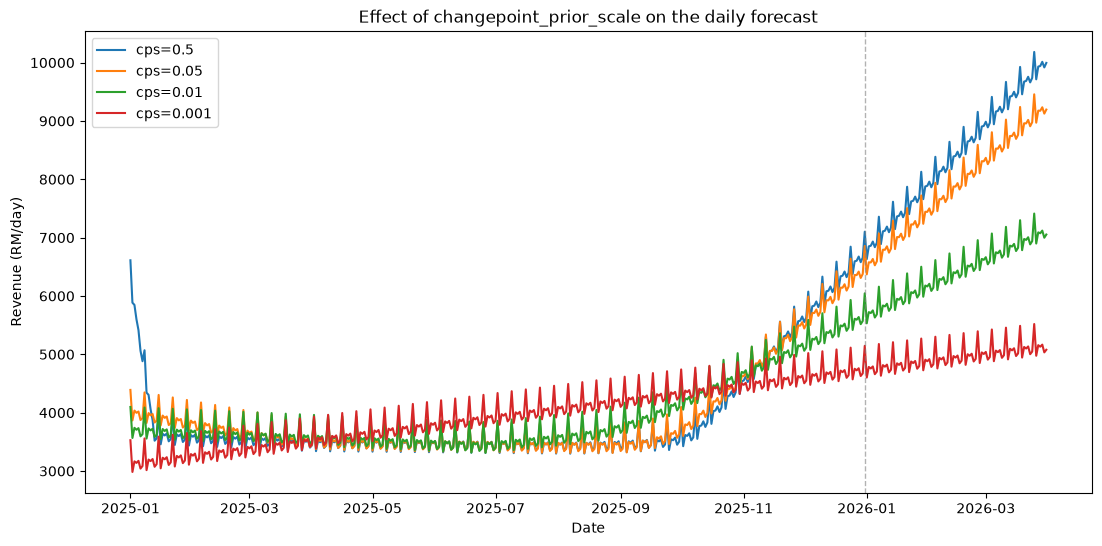


Reference: Jan-Oct 2025 baseline was ~RM 3,500/day (~105k/month).


In [16]:
cps_values = [0.5, 0.05, 0.01, 0.001]    # 0.05 is Prophet's default

fig, ax = plt.subplots(figsize=(13, 6))
#creata blank plot

print(f"{'cps':>8} {'RM/day':>10} {'~RM/month':>12}")


for cps in cps_values:
    m = Prophet(yearly_seasonality=False, weekly_seasonality=True,
                daily_seasonality=False, changepoint_prior_scale=cps)
    m.fit(daily)
    fc = m.predict(m.make_future_dataframe(periods=90, freq="D"))
    ax.plot(fc["ds"], fc["yhat"], label=f"cps={cps}")
    end = fc["yhat"].iloc[-1]
    print(f"{cps:>8} {end:>10.0f} {end*30:>12.0f}" + ("  <- default" if cps==0.05 else ""))
#test diffrent cps values

ax.axvline(daily["ds"].max(), color="gray", ls="--", lw=1, alpha=0.6)
ax.set_title("Effect of changepoint_prior_scale on the daily forecast")
ax.set_xlabel("Date"); ax.set_ylabel("Revenue (RM/day)")
ax.legend()
plt.show()

#plot graph
print("\nReference: Jan-Oct 2025 baseline was ~RM 3,500/day (~105k/month).")

#cps = how strict the model is about the trend line